# RLHF Results

Run all cells to generate the paper figures (written straight into the Overleaf clone, `Paper/ICLR/Figures/RLHF/`) and the full results for all scenarios.

In [1]:
import json
import os
import re
import yaml
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from glob import glob

# Configure matplotlib
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-darkgrid')

In [2]:
# ============================================
# Configuration
# ============================================
# Roots follow tables/common.py (same as SFT/result.ipynb and the table generators): results from $DRPT_RESULTS
# (else $SCRATCH_DIR/Dr.Post-Training), paper from $DRPT_PAPER (else ../Paper, the Overleaf clone).
import sys
sys.path.insert(0, os.path.abspath('..'))
from tables.common import results_root, paper_root
out_dir = str(results_root() / 'RLHF')
config_dir = './train/configs/toxicity'
paper_fig_dir = str(paper_root() / 'ICLR' / 'Figures' / 'RLHF')   # paper figures, written in place (no copy step)
aux_dir = './figures'                                             # companions not in the paper
os.makedirs(paper_fig_dir, exist_ok=True)
os.makedirs(aux_dir, exist_ok=True)

def load_yaml_config(config_dir, method_name=None):
    """Load defaults.yaml, optionally overlaid with method config."""
    cfg = {}
    defaults_path = os.path.join(config_dir, 'defaults.yaml')
    if os.path.exists(defaults_path):
        with open(defaults_path) as f:
            cfg.update(yaml.safe_load(f))
    if method_name:
        method_path = os.path.join(config_dir, f'{method_name}.yaml')
        if os.path.exists(method_path):
            with open(method_path) as f:
                method_cfg = yaml.safe_load(f)
                if method_cfg:
                    cfg.update(method_cfg)
    return cfg

# Load shared defaults
shared_config = load_yaml_config(config_dir)
task = shared_config.get('task', 'toxicity')
model = os.path.basename(shared_config.get('model', 'gpt-neo-2.7B'))
print(f"Loaded config from {config_dir}/defaults.yaml")
print(f"Task: {task}, Model: {model}")

# Methods
# TargetOnly = plain PPO on the n_val held-out prompts only (held-out scenarios only).
ALL_METHODS = ['FullTraining-LoRA', 'TargetOnly-LoRA', 'IIF-LoRA', 'LayerWiseSubset-LoRA', 'GlobalSubset-LoRA']

LEGEND_NAMES = {
    'FullTraining-LoRA': 'Full-Training',
    'TargetOnly-LoRA': 'Target-Only',
    'IIF-LoRA': 'IIF',
    'LayerWiseSubset-LoRA': 'Layer-Wise Subset',
    'GlobalSubset-LoRA': 'Global Subset',
}

METHOD_COLORS = {
    'FullTraining-LoRA': 'black',
    'TargetOnly-LoRA': 'gray',
    'IIF-LoRA': 'blue',
    'LayerWiseSubset-LoRA': 'red',
    'GlobalSubset-LoRA': 'green',
}

# All scenarios. val_loss_type uses the canonical --val_loss_type names
# (reward | token-pg | train-loss); run dirs use the short forms below.
#   reward     : -E[normalize(R) * log pi(y|x)]              (sequence-level)
#   token-pg   : -sum_t A_t log pi(y_t|.)                    (token-level PG = PPO surrogate at ratio 1)
#   train-loss : clipped PPO surrogate + vf_coef * value loss (the training objective)
# n_val = 0 -> self-referencing target (training rollouts); n_val > 0 -> held-out prompts.
SCENARIOS = {
    'self-ref / reward':     {'n_val': 0,    'val_loss_type': 'reward'},
    'self-ref / token-pg':   {'n_val': 0,    'val_loss_type': 'token-pg'},
    'self-ref / train-loss': {'n_val': 0,    'val_loss_type': 'train-loss'},
    'held-out / reward':     {'n_val': 1024, 'val_loss_type': 'reward'},
    'held-out / token-pg':   {'n_val': 1024, 'val_loss_type': 'token-pg'},
    'held-out / train-loss': {'n_val': 1024, 'val_loss_type': 'train-loss'},
}

# Must match the case statement in train/train.sh.
VAL_TYPE_SHORT = {'reward': 'rew', 'token-pg': 'tpg', 'train-loss': 'tloss'}

print(f"Scenarios: {len(SCENARIOS)}")
print(f"Methods: {', '.join(ALL_METHODS)}")

# ============================================
# Paper figures (ICLR)
# ============================================
# Scoring backends. The method part of a run-dir name carries a suffix for the compressed-scoring runs
# (dense Gaussian 64x64); Full-Training does no scoring and is shared by both backends.
# Paper convention: exact PIP = main text (fig:RLHF, fig:RLHF-judges); compressed = appendix
# LoRA-compatibility ablation (fig:RLHF-compressed, adxsubsubsec:rlhf-scoring-backend).
SCORING_SUFFIX = {'exact': '', 'cmp': '-cmp-normal-64x64'}
PAPER_METHODS = [m for m in ALL_METHODS if m != 'TargetOnly-LoRA']   # Target-Only is not in the paper
PAPER_SCENARIOS = ['self-ref / reward', 'self-ref / train-loss', 'held-out / reward', 'held-out / train-loss']
# File names in Paper/ICLR/Figures/RLHF: exact -> <name>.pdf, compressed -> compressed_<name>.pdf.
PAPER_FIG_PREFIX = {'exact': '', 'cmp': 'compressed_'}

def paper_fig_path(scoring, name):
    """Paper/ICLR/Figures/RLHF/<prefix><name> for one scoring backend."""
    return os.path.join(paper_fig_dir, PAPER_FIG_PREFIX[scoring] + name)
print(f"Paper: {len(PAPER_SCENARIOS)} scenarios x {len(PAPER_METHODS)} methods x backends {list(SCORING_SUFFIX)}")


Loaded config from ./train/configs/toxicity/defaults.yaml
Task: toxicity, Model: gpt-neo-2.7B
Scenarios: 6
Methods: FullTraining-LoRA, TargetOnly-LoRA, IIF-LoRA, LayerWiseSubset-LoRA, GlobalSubset-LoRA
Paper: 4 scenarios x 4 methods x backends ['exact', 'cmp']


## Helper Functions & Load All Data

In [3]:
# ============================================
# Helper functions (parameterized by scenario)
# ============================================

_config_cache = {}

def _method_config(method_name):
    """Load merged config (defaults + method overrides) from YAML."""
    if method_name not in _config_cache:
        _config_cache[method_name] = load_yaml_config(config_dir, method_name)
    return _config_cache[method_name]

def _lr(method_name):
    # train.sh writes the YAML value verbatim into the run name (e.g. "1e-5").
    cfg = _method_config(method_name)
    return str(cfg.get('learning_rate', '1e-5'))

def _kl(method_name):
    cfg = _method_config(method_name)
    return float(cfg.get('init_kl_coef', 0.02))

def _dir_name(method_name, seed, scfg, scoring='exact'):
    """Build directory name for a method + scenario + seed (+ scoring backend, see SCORING_SUFFIX)."""
    cfg = _method_config(method_name)
    method, finetuning = method_name.split('-', 1)
    lr = _lr(method_name)
    kl_coef = _kl(method_name)
    # FullTraining never uses a target: train.sh files it under v0-rew for every scenario.
    if method == 'FullTraining':
        scfg = {'n_val': 0, 'val_loss_type': 'reward'}
    # TargetOnly trains on the n_val held-out prompts: only meaningful for held-out scenarios.
    if method == 'TargetOnly':
        if scfg['n_val'] == 0:
            return '__no_target_only_for_self_ref__'
        scfg = {'n_val': scfg['n_val'], 'val_loss_type': 'reward'}
    vlt_short = VAL_TYPE_SHORT[scfg['val_loss_type']]
    val_str = f"v{scfg['n_val']}-{vlt_short}"
    if scfg['n_val'] > 0:
        val_str = f"{val_str}-b{cfg.get('val_batch_size', 256)}"
    # Only the scoring methods carry the backend suffix (train.sh appends it to the method name).
    if method not in ('FullTraining', 'TargetOnly'):
        method = f"{method}{SCORING_SUFFIX[scoring]}"
    return (f"{task}-{model}-{method}-{finetuning}"
            f"-lr{lr}-b{cfg.get('batch_size', 256)}-{val_str}"
            f"-pe{cfg.get('ppo_epochs', 4)}-mb{cfg.get('mini_batch_size', 4)}"
            f"-kl{kl_coef}-s{seed}")

def _discover_seeds(method_name, scfg, scoring='exact'):
    pattern = _dir_name(method_name, '*', scfg, scoring)
    seeds = []
    for p in glob(f"{out_dir}/{pattern}"):
        m = re.search(r'-s(\d+)$', Path(p).name)
        if m:
            seeds.append(int(m.group(1)))
    return sorted(seeds)

def _load_history(path):
    with open(path, 'r') as f:
        h = json.load(f)
    n = len(h.get('reward', []))
    return {
        'steps': np.arange(n),
        'reward_mean': np.array(h.get('reward', [])),
        'kl': np.array(h.get('kl', [])),
        'batch_toxicity': np.array(h.get('toxicity_prob', [])),
        'eval_toxicity_steps': np.array(h.get('full_eval_steps', [])),
        'eval_toxicity': np.array(h.get('full_eval_toxicity_prob', [])),
    }

def _load_log(path):
    steps, rewards, kls, btox = [], [], [], []
    etox, etox_steps = [], []
    with open(path, 'r') as f:
        for line in f:
            if 'Step ' in line and 'Eval step' not in line:
                try:
                    sm = re.search(r'Step (\d+):', line)
                    if not sm: continue
                    step = int(sm.group(1))
                    metrics = None
                    if '{' in line:
                        try:
                            metrics = json.loads(line[line.index('{'):line.rindex('}')+1].replace("'", '"'))
                        except: pass
                    if metrics is None:
                        metrics = {}
                        for k, v in re.findall(r'(\w+)=([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)', line):
                            val = float(v)
                            if k == 'reward': metrics['reward/mean'] = val
                            elif k == 'kl': metrics['objective/kl'] = val
                            elif k == 'tox': metrics['eval/toxicity_prob'] = val
                    if metrics:
                        steps.append(step)
                        rewards.append(metrics.get('reward/mean', 0))
                        kls.append(metrics.get('objective/kl', 0))
                        btox.append(metrics.get('eval/toxicity_prob', 0))
                except: continue
            elif '[Eval step' in line and 'toxicity:' in line:
                try:
                    m = re.search(r'\[Eval step (\d+)\] toxicity: ([\d.]+)', line)
                    if m: etox_steps.append(int(m.group(1))); etox.append(float(m.group(2)))
                except: continue
    return {
        'steps': np.array(steps), 'reward_mean': np.array(rewards),
        'kl': np.array(kls), 'batch_toxicity': np.array(btox),
        'eval_toxicity_steps': np.array(etox_steps), 'eval_toxicity': np.array(etox),
    }

def _load_exp(exp_path):
    for fname, loader, src in [('training_history.json', _load_history, 'history'), ('train.log', _load_log, 'log')]:
        p = f"{exp_path}/{fname}"
        if Path(p).exists():
            try: return loader(p), src
            except Exception as e: print(f"  Warning: {p}: {e}")
    return None, None

def load_method(method_name, scfg, scoring='exact'):
    """Load and aggregate results across seeds for a method + scenario (+ scoring backend)."""
    seeds = _discover_seeds(method_name, scfg, scoring)
    if not seeds: return None
    all_res, valid_seeds = [], []
    for seed in seeds:
        result, _ = _load_exp(f"{out_dir}/{_dir_name(method_name, seed, scfg, scoring)}")
        if result is not None and len(result['steps']) > 0:
            all_res.append(result); valid_seeds.append(seed)
    if not all_res: return None
    n_seeds = len(valid_seeds)
    se = np.sqrt(n_seeds)  # standard error denominator
    ml = min(len(r['steps']) for r in all_res)
    def _s(k): return np.stack([r[k][:ml] for r in all_res])
    reward, kl, btox = _s('reward_mean'), _s('kl'), _s('batch_toxicity')
    eml = min(len(r['eval_toxicity']) for r in all_res) if all(len(r['eval_toxicity']) > 0 for r in all_res) else 0
    if eml > 0:
        etox = np.stack([r['eval_toxicity'][:eml] for r in all_res])
        etox_steps = all_res[0]['eval_toxicity_steps'][:eml]
    else:
        etox, etox_steps = np.array([]).reshape(0,0), np.array([])
    return {
        'steps': all_res[0]['steps'][:ml],
        'reward_mean_mean': np.mean(reward, 0), 'reward_mean_std': np.std(reward, 0) / se,
        'kl_mean': np.mean(kl, 0), 'kl_std': np.std(kl, 0) / se,
        'batch_toxicity_mean': np.mean(btox, 0), 'batch_toxicity_std': np.std(btox, 0) / se,
        'eval_toxicity_steps': etox_steps,
        'eval_toxicity_mean': np.mean(etox, 0) if eml > 0 else np.array([]),
        'eval_toxicity_std': np.std(etox, 0) / se if eml > 0 else np.array([]),
        'n_seeds': n_seeds, 'seeds': valid_seeds,
    }

# ============================================
# Load ALL scenarios upfront
# ============================================
# all_data[scenario_name][method_name] = {...}
all_data = {}

for sname, scfg in SCENARIOS.items():
    print(f"\n{'='*60}")
    print(f"Loading: {sname}")
    print(f"{'='*60}")

    sdata = {}
    for method_name in ALL_METHODS:
        data = load_method(method_name, scfg)
        if data:
            sdata[method_name] = data
            print(f"  + {method_name}: {data['n_seeds']} seeds, {len(data['steps'])} points")
        else:
            pattern = _dir_name(method_name, '*', scfg)
            print(f"  - {method_name}: Not found ({pattern})")

    all_data[sname] = sdata
    print(f"  Loaded {len(sdata)}/{len(ALL_METHODS)} methods")

print(f"\n{'='*60}")
print(f"All {len(all_data)} scenarios loaded.")
print(f"{'='*60}")

# ============================================
# Compressed-scoring runs (paper scenarios/methods only)
# ============================================
# all_data_by_scoring[scoring][scenario_name][method_name] = {...}; 'exact' is all_data from above.
all_data_cmp = {}
for sname in PAPER_SCENARIOS:
    scfg = SCENARIOS[sname]
    sdata = {}
    for method_name in PAPER_METHODS:
        data = load_method(method_name, scfg, scoring='cmp')
        if data:
            sdata[method_name] = data
        else:
            print(f"  - [cmp] {sname} / {method_name}: Not found ({_dir_name(method_name, '*', scfg, 'cmp')})")
    all_data_cmp[sname] = sdata
    print(f"  [cmp] {sname}: {len(sdata)}/{len(PAPER_METHODS)} methods, "
          + ", ".join(f"{LEGEND_NAMES[m]}={d['n_seeds']} seeds" for m, d in sdata.items()))

all_data_by_scoring = {'exact': all_data, 'cmp': all_data_cmp}


Loading: self-ref / reward


  + FullTraining-LoRA: 5 seeds, 111 points
  - TargetOnly-LoRA: Not found (__no_target_only_for_self_ref__)


  + IIF-LoRA: 5 seeds, 111 points


  + LayerWiseSubset-LoRA: 5 seeds, 111 points


  + GlobalSubset-LoRA: 5 seeds, 111 points
  Loaded 4/5 methods

Loading: self-ref / token-pg


...

  + GlobalSubset-LoRA: 5 seeds, 111 points
  Loaded 5/5 methods

All 6 scenarios loaded.


  [cmp] self-ref / reward: 4/4 methods, Full-Training=5 seeds, IIF=5 seeds, Layer-Wise Subset=5 seeds, Global Subset=5 seeds


  [cmp] self-ref / train-loss: 4/4 methods, Full-Training=5 seeds, IIF=5 seeds, Layer-Wise Subset=5 seeds, Global Subset=5 seeds


  [cmp] held-out / reward: 4/4 methods, Full-Training=5 seeds, IIF=5 seeds, Layer-Wise Subset=5 seeds, Global Subset=5 seeds


  [cmp] held-out / train-loss: 4/4 methods, Full-Training=5 seeds, IIF=5 seeds, Layer-Wise Subset=5 seeds, Global Subset=5 seeds


## Paper Figures: Reward + Eval Toxicity (per scenario, per scoring backend)

One publication-ready PDF per paper scenario and scoring backend over the first 80 of the 110 PPO steps, shared axes across all scenarios and both backends: Reward (top) + Eval Toxicity (bottom). Reward-target scenarios annotate convergence speed on the reward panel (dashed line at Full-Training's step-80 reward, markers at the first step each method reaches it, one double-headed arrow per method with its speed-up over Full-Training); train-loss scenarios get a faithful 5x zoom on the final steps instead (all methods end at the same level). Written straight into the Overleaf clone: `Paper/ICLR/Figures/RLHF/<scenario>.pdf` + `legend.pdf` (exact, `fig:RLHF`, main text) and `compressed_<scenario>.pdf` + `compressed_legend.pdf` (compressed, `fig:RLHF-compressed`, appendix).



############################################################
  Variant 'main': max_step=80, speed annotation for ['reward'], zoom inset for ['train-loss']
############################################################
[reward] x_max=80, y=(2.7004, 4.7870), ticks=[3.0, 3.5, 4.0, 4.5], zoom inset
[eval_tox] x_max=80, y=(-0.0024, 0.1321), ticks=[0.0, 0.03, 0.06, 0.09, 0.12]

  [exact] self-ref / reward


    [reward] + FullTraining-LoRA: 5 seeds, final=4.5692
    [reward] + IIF-LoRA: 5 seeds, final=4.6449
    [reward] + LayerWiseSubset-LoRA: 5 seeds, final=4.6612
    [reward] + GlobalSubset-LoRA: 5 seeds, final=4.6781
    [speed] reference: Full-Training reward 4.5692 at step 80; first crossing: Layer-Wise Subset=14.6, Global Subset=24.5, IIF=37.2 ; speed-up: Layer-Wise Subset=5.5x, Global Subset=3.3x, IIF=2.2x
    [eval_tox] + FullTraining-LoRA: 5 seeds, final=0.0800
    [eval_tox] + IIF-LoRA: 5 seeds, final=0.0285
    [eval_tox] + LayerWiseSubset-LoRA: 5 seeds, final=0.0096
    [eval_tox] + GlobalSubset-LoRA: 5 seeds, final=0.0095


    -> Saved: ./figures/paper_exact/self-ref_reward.pdf


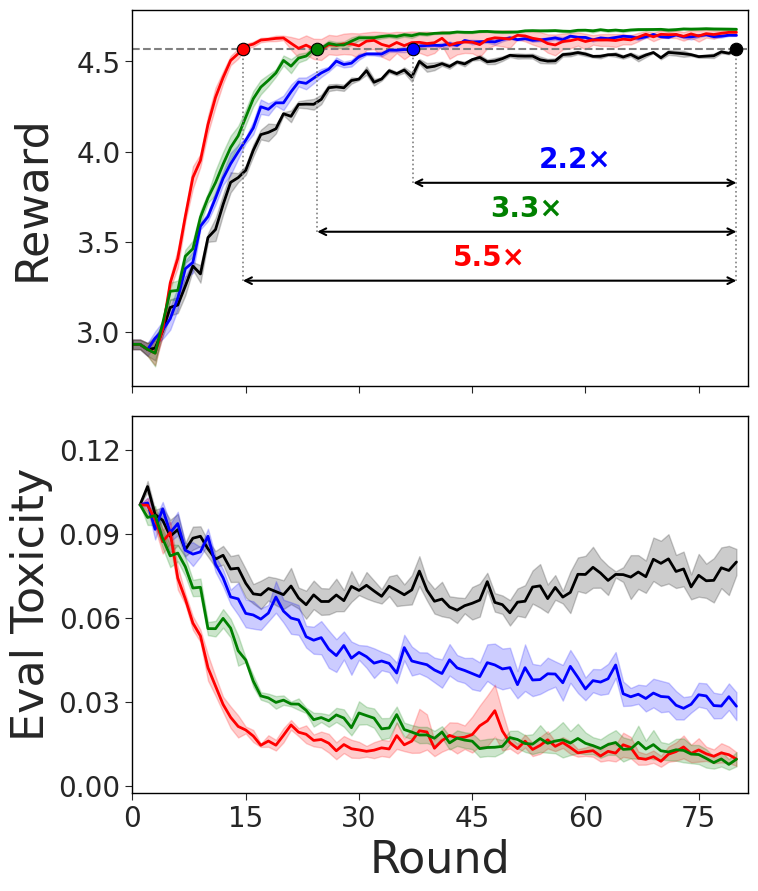


  [exact] self-ref / train-loss
    [reward] + FullTraining-LoRA: 5 seeds, final=4.5692
    [reward] + IIF-LoRA: 5 seeds, final=4.5388
    [reward] + LayerWiseSubset-LoRA: 5 seeds, final=4.5342
    [reward] + GlobalSubset-LoRA: 5 seeds, final=4.5284
    [inset] rounds [75.7, 80] x reward [4.4453, 4.6456]; box 0.36x0.36 in -> inset 1.81x1.81 in (5.0x magnification, box == inset limits)
    [eval_tox] + FullTraining-LoRA: 5 seeds, final=0.0800
    [eval_tox] + IIF-LoRA: 5 seeds, final=0.0748
    [eval_tox] + LayerWiseSubset-LoRA: 5 seeds, final=0.0594
    [eval_tox] + GlobalSubset-LoRA: 5 seeds, final=0.0531
    -> Saved: ./figures/paper_exact/self-ref_train-loss.pdf


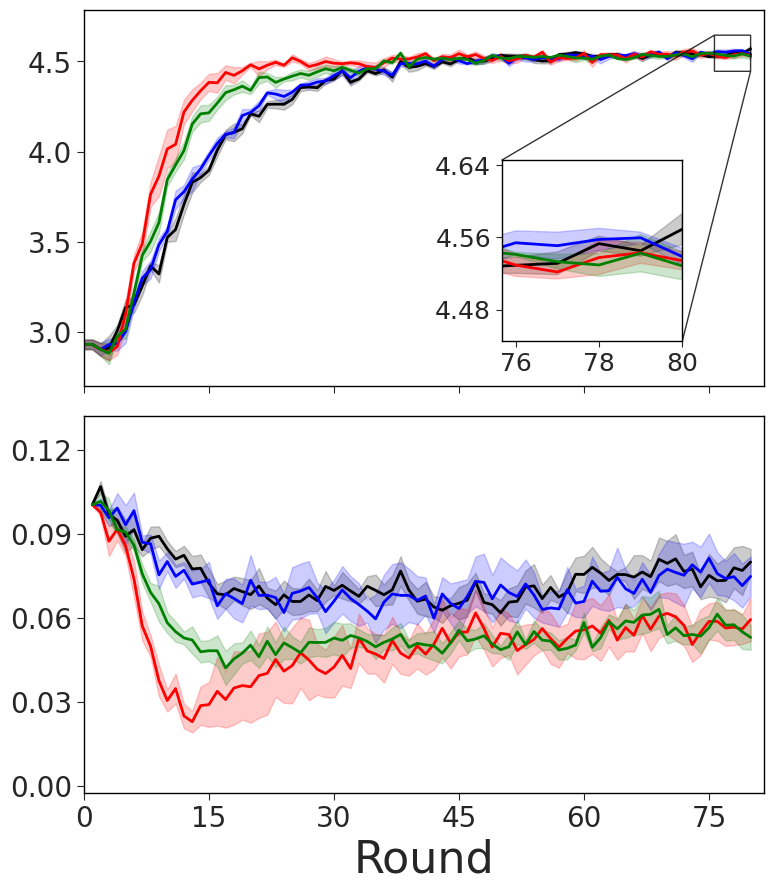


  [exact] held-out / reward
    [reward] + FullTraining-LoRA: 5 seeds, final=4.5692
    [reward] + IIF-LoRA: 5 seeds, final=4.6620
    [reward] + LayerWiseSubset-LoRA: 5 seeds, final=4.6589
    [reward] + GlobalSubset-LoRA: 5 seeds, final=4.6909
    [speed] reference: Full-Training reward 4.5692 at step 80; first crossing: Layer-Wise Subset=12.9, Global Subset=18.8, IIF=32.0 ; speed-up: Layer-Wise Subset=6.2x, Global Subset=4.3x, IIF=2.5x
    [eval_tox] + FullTraining-LoRA: 5 seeds, final=0.0800
    [eval_tox] + IIF-LoRA: 5 seeds, final=0.0162
    [eval_tox] + LayerWiseSubset-LoRA: 5 seeds, final=0.0094
    [eval_tox] + GlobalSubset-LoRA: 5 seeds, final=0.0105
    -> Saved: ./figures/paper_exact/held-out_reward.pdf


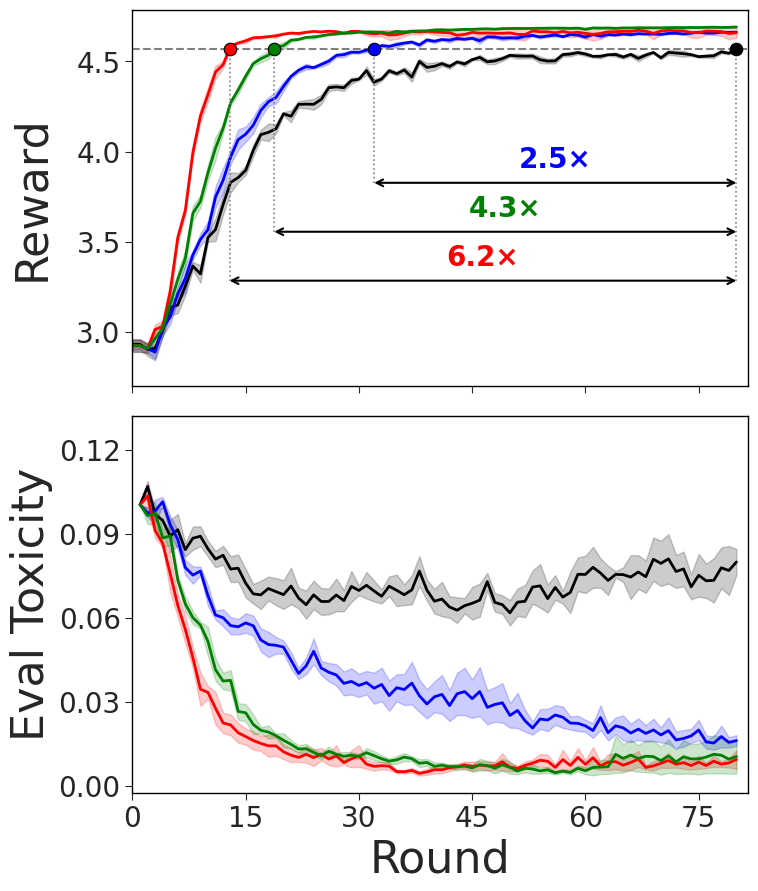


  [exact] held-out / train-loss
    [reward] + FullTraining-LoRA: 5 seeds, final=4.5692
    [reward] + IIF-LoRA: 5 seeds, final=4.5417
    [reward] + LayerWiseSubset-LoRA: 5 seeds, final=4.5585
    [reward] + GlobalSubset-LoRA: 5 seeds, final=4.5213
    [inset] rounds [75.7, 80] x reward [4.4384, 4.6387]; box 0.36x0.36 in -> inset 1.81x1.81 in (5.0x magnification, box == inset limits)
    [eval_tox] + FullTraining-LoRA: 5 seeds, final=0.0800
    [eval_tox] + IIF-LoRA: 5 seeds, final=0.0669
    [eval_tox] + LayerWiseSubset-LoRA: 5 seeds, final=0.0736
    [eval_tox] + GlobalSubset-LoRA: 5 seeds, final=0.0724
    -> Saved: ./figures/paper_exact/held-out_train-loss.pdf


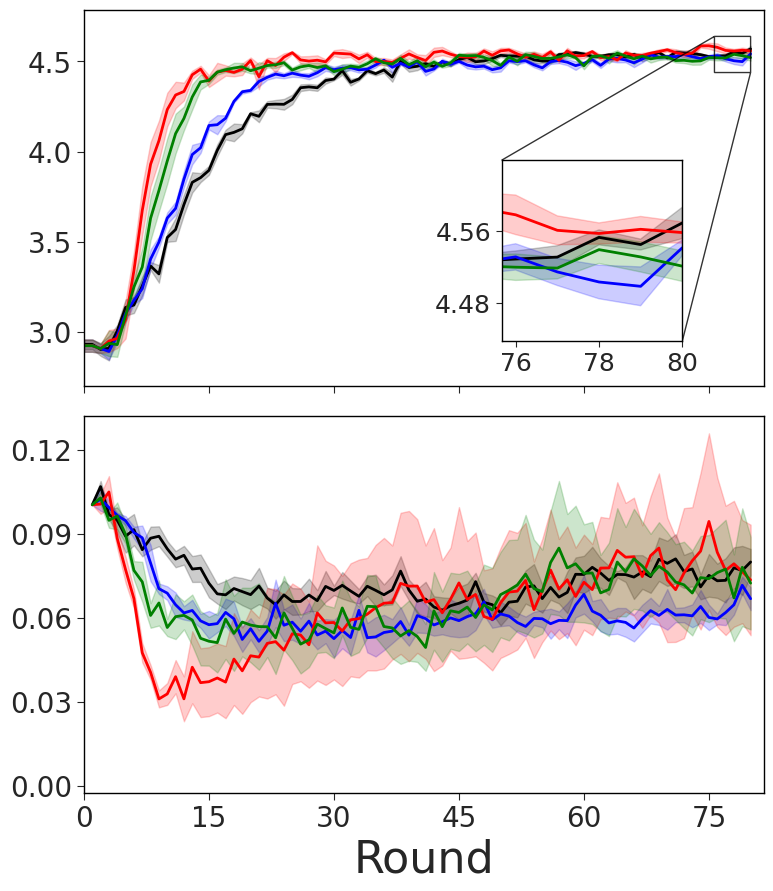


  [cmp] self-ref / reward
    [reward] + FullTraining-LoRA: 5 seeds, final=4.5692
    [reward] + IIF-LoRA: 5 seeds, final=4.6313
    [reward] + LayerWiseSubset-LoRA: 5 seeds, final=4.6549
    [reward] + GlobalSubset-LoRA: 5 seeds, final=4.6714
    [speed] reference: Full-Training reward 4.5692 at step 80; first crossing: Layer-Wise Subset=24.5, Global Subset=25.8, IIF=33.8 ; speed-up: Layer-Wise Subset=3.3x, Global Subset=3.1x, IIF=2.4x
    [eval_tox] + FullTraining-LoRA: 5 seeds, final=0.0800
    [eval_tox] + IIF-LoRA: 5 seeds, final=0.0278
    [eval_tox] + LayerWiseSubset-LoRA: 5 seeds, final=0.0079
    [eval_tox] + GlobalSubset-LoRA: 5 seeds, final=0.0103
    -> Saved: ./figures/paper_cmp/self-ref_reward.pdf


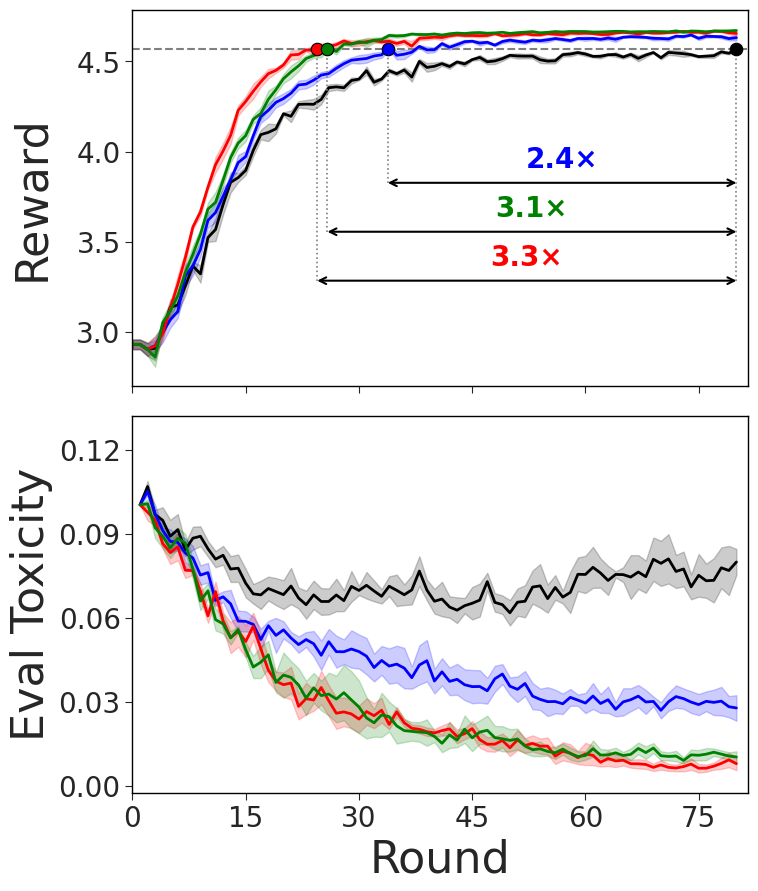


  [cmp] self-ref / train-loss
    [reward] + FullTraining-LoRA: 5 seeds, final=4.5692
    [reward] + IIF-LoRA: 5 seeds, final=4.5574
    [reward] + LayerWiseSubset-LoRA: 5 seeds, final=4.5342
    [reward] + GlobalSubset-LoRA: 5 seeds, final=4.5444
    [inset] rounds [75.7, 80] x reward [4.4435, 4.6439]; box 0.36x0.36 in -> inset 1.81x1.81 in (5.0x magnification, box == inset limits)
    [eval_tox] + FullTraining-LoRA: 5 seeds, final=0.0800
    [eval_tox] + IIF-LoRA: 5 seeds, final=0.0551
    [eval_tox] + LayerWiseSubset-LoRA: 5 seeds, final=0.0761
    [eval_tox] + GlobalSubset-LoRA: 5 seeds, final=0.0710
    -> Saved: ./figures/paper_cmp/self-ref_train-loss.pdf


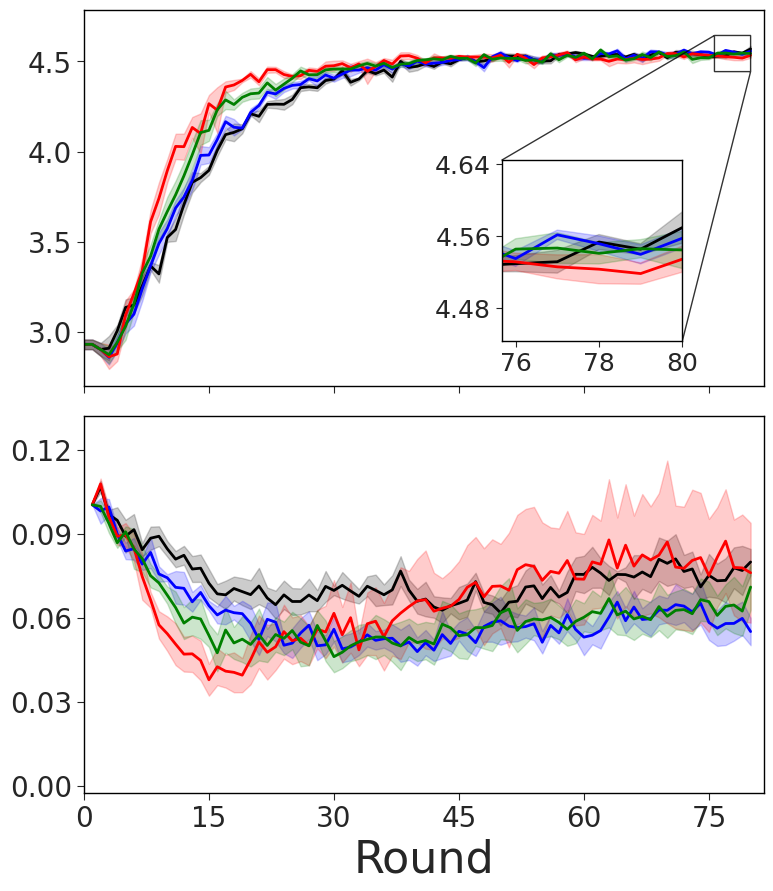


  [cmp] held-out / reward
    [reward] + FullTraining-LoRA: 5 seeds, final=4.5692
    [reward] + IIF-LoRA: 5 seeds, final=4.6555
    [reward] + LayerWiseSubset-LoRA: 5 seeds, final=4.6006
    [reward] + GlobalSubset-LoRA: 5 seeds, final=4.6732
    [speed] reference: Full-Training reward 4.5692 at step 80; first crossing: Layer-Wise Subset=21.8, Global Subset=28.0, IIF=37.6 ; speed-up: Layer-Wise Subset=3.7x, Global Subset=2.9x, IIF=2.1x
    [eval_tox] + FullTraining-LoRA: 5 seeds, final=0.0800
    [eval_tox] + IIF-LoRA: 5 seeds, final=0.0196
    [eval_tox] + LayerWiseSubset-LoRA: 5 seeds, final=0.0067
    [eval_tox] + GlobalSubset-LoRA: 5 seeds, final=0.0153
    -> Saved: ./figures/paper_cmp/held-out_reward.pdf


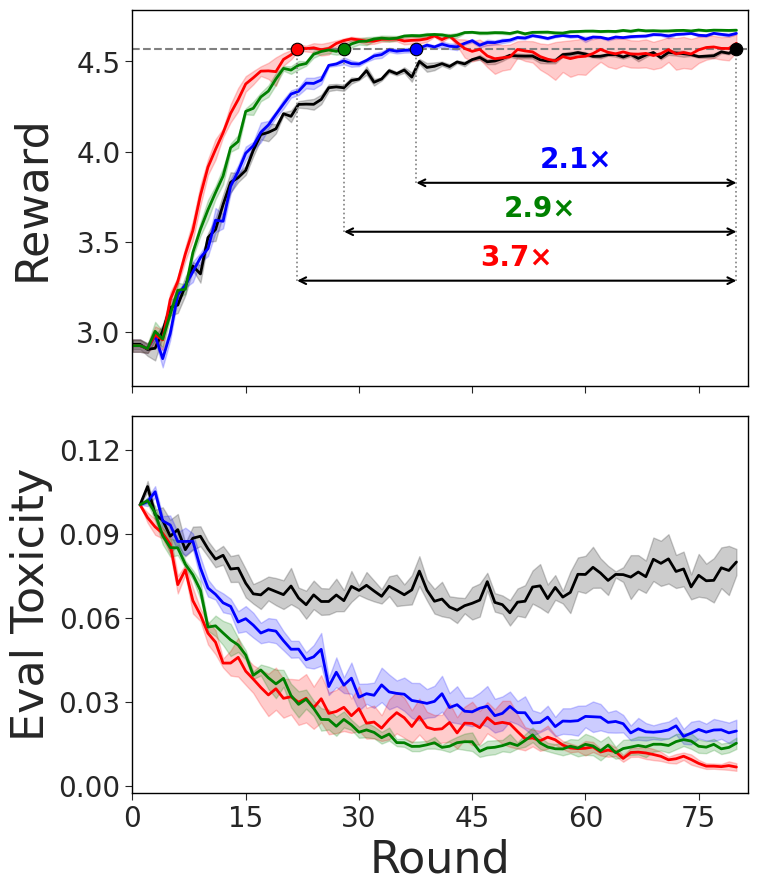


  [cmp] held-out / train-loss
    [reward] + FullTraining-LoRA: 5 seeds, final=4.5692
    [reward] + IIF-LoRA: 5 seeds, final=4.5240
    [reward] + LayerWiseSubset-LoRA: 5 seeds, final=4.3910
    [reward] + GlobalSubset-LoRA: 5 seeds, final=4.5348
    [inset] rounds [75.3, 80] x reward [4.3673, 4.5845]; box 0.39x0.39 in -> inset 1.81x1.81 in (4.6x magnification, box == inset limits)
    [eval_tox] + FullTraining-LoRA: 5 seeds, final=0.0800
    [eval_tox] + IIF-LoRA: 5 seeds, final=0.0511
    [eval_tox] + LayerWiseSubset-LoRA: 5 seeds, final=0.0907
    [eval_tox] + GlobalSubset-LoRA: 5 seeds, final=0.0672
    -> Saved: ./figures/paper_cmp/held-out_train-loss.pdf


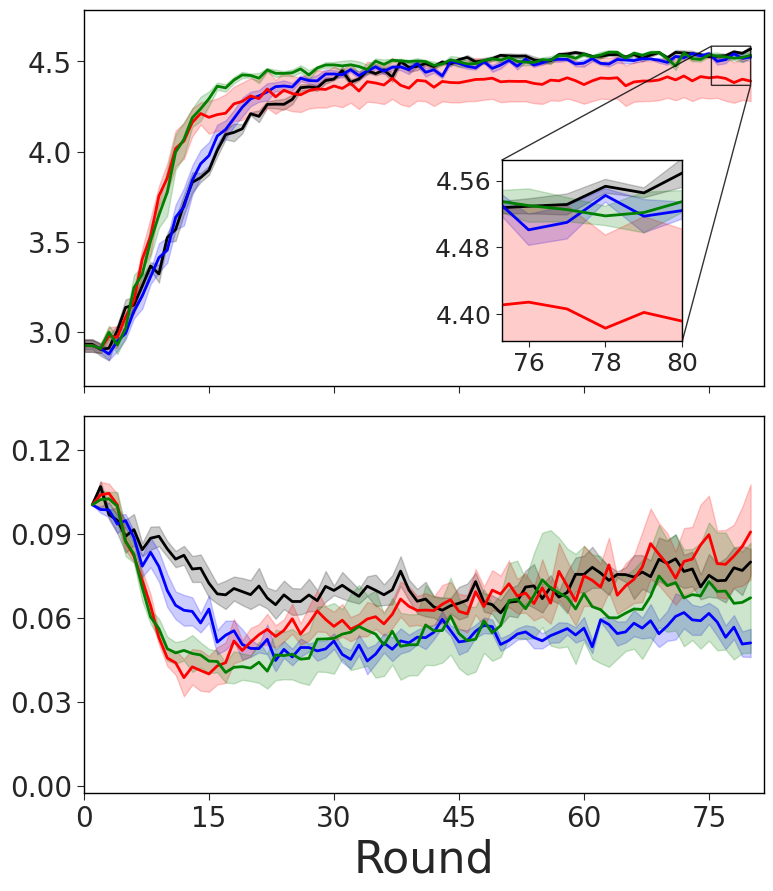

Saved legend: ./figures/paper_exact/legend.pdf
Saved legend: ./figures/paper_cmp/legend.pdf


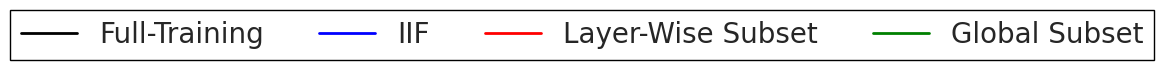

In [4]:
# Paper figures: combined Reward (top) + Eval Toxicity (bottom) per scenario, sharex,
# one PDF per (scoring backend, scenario) -> paper_fig_path(scoring, '<scenario>.pdf') in Paper/ICLR/Figures/RLHF
from matplotlib.ticker import MaxNLocator

# Paper figures show the first PAPER_MAX_STEP of the 110 PPO steps (exact and compressed backend alike): the figure
# is about convergence speed, and the late plateau (all rewards saturated, ordering within noise) is an artefact of
# training for the full epoch. Set max_step=None for the complete runs (e.g. prefix 'full_').
PAPER_MAX_STEP = 80
PAPER_VARIANTS = [
    # fig:RLHF (main text) / fig:RLHF-compressed (appendix). Per target loss: the expected-reward target gets the
    # convergence-speed annotation (methods converge to Full-Training's level several times faster); the train-loss
    # target gets the faithful plateau zoom (methods end at the same level, no benefit).
    {'prefix': '', 'max_step': PAPER_MAX_STEP, 'speed_annot_for': {'reward'}, 'inset_for': {'train-loss'}},
]

# Convergence-speed annotation on the reward panel: a dashed line at the reward Full-Training reaches at the last
# plotted step (its plotted mean at that step, so its reference marker lies exactly on its curve), a marker exactly
# where each other method's plotted mean curve first crosses that level (linear interpolation between the two
# bracketing steps), and one double-headed horizontal arrow per method in the empty lower part of the panel, from
# its crossing to the reference step, labelled with the speed-up factor (reference step / crossing step). Arrows are
# stacked: the fastest method's (longest) arrow at the bottom. Dotted guides drop from the markers to the arrows.
# Methods whose curve never reaches the level before the reference step get no marker and no arrow.
SPEED_FONTSIZE = 20
SPEED_ARROW_Y0 = 0.28     # height of the lowest (fastest) arrow, axes fraction
SPEED_ARROW_DY = 0.13     # vertical spacing between stacked arrows, axes fraction
SPEED_LABEL_DY = 0.025    # label offset above its arrow, axes fraction

def _first_crossing(x, y, thr):
    """x where the polyline (x, y) first reaches thr (linear interpolation); None if never."""
    idx = np.where(y >= thr)[0]
    if len(idx) == 0:
        return None
    i = int(idx[0])
    if i == 0 or y[i] == y[i - 1]:
        return float(x[i])
    return float(x[i - 1] + (thr - y[i - 1]) / (y[i] - y[i - 1]) * (x[i] - x[i - 1]))

def _speed_annotation(ax, panel_by_method, full_method='FullTraining-LoRA'):
    """Dashed reference line + on-curve first-crossing markers + one speed-up arrow per method; returns crossings."""
    if full_method not in panel_by_method:
        return {}
    x_full, y_full, _ = panel_by_method[full_method]
    x_ref, thr = float(x_full[-1]), float(y_full[-1])         # reference: Full-Training's plotted point at the last step
    crossings = {full_method: x_ref}
    for method_name, (x, y, _) in panel_by_method.items():
        if method_name == full_method:
            continue
        t = _first_crossing(x, y, thr)
        if t is not None and t < x_ref:
            crossings[method_name] = t
    ax.axhline(thr, color='gray', linestyle='--', linewidth=1.5, zorder=1)
    for method_name, t in crossings.items():
        ax.plot([t], [thr], marker='o', markersize=9, color=METHOD_COLORS[method_name],
                markeredgecolor='black', markeredgewidth=0.8, linestyle='none', zorder=5)
    others = sorted((m for m in crossings if m != full_method), key=lambda m: crossings[m])   # fastest first
    y0, y1 = ax.get_ylim()
    for k, method_name in enumerate(others):
        t = crossings[method_name]
        y_arrow = y0 + (SPEED_ARROW_Y0 + k * SPEED_ARROW_DY) * (y1 - y0)
        ax.plot([t, t], [y_arrow, thr], linestyle=':', color='gray', linewidth=1.2, zorder=2)
        ax.annotate('', xy=(x_ref, y_arrow), xytext=(t, y_arrow),
                    arrowprops=dict(arrowstyle='<->', color='black', linewidth=1.5, shrinkA=0, shrinkB=0), zorder=4)
        ax.text((t + x_ref) / 2, y_arrow + SPEED_LABEL_DY * (y1 - y0), f"{x_ref / t:.1f}×",
                ha='center', va='bottom', fontsize=SPEED_FONTSIZE, fontweight='bold',
                color=METHOD_COLORS[method_name], zorder=6)
    if others:
        y_low = y0 + SPEED_ARROW_Y0 * (y1 - y0)
        ax.plot([x_ref, x_ref], [y_low, thr], linestyle=':', color='gray', linewidth=1.2, zorder=2)
    print(f"    [speed] reference: Full-Training reward {thr:.4f} at step {x_ref:g}; first crossing: "
          + ", ".join(f"{LEGEND_NAMES[m]}={crossings[m]:.1f}" for m in others)
          + " ; speed-up: " + ", ".join(f"{LEGEND_NAMES[m]}={x_ref / crossings[m]:.1f}x" for m in others)
          + (" ; never reaches the level: " + ", ".join(LEGEND_NAMES[m] for m in panel_by_method if m not in crossings)
             if any(m not in crossings for m in panel_by_method) else ""))
    return crossings

PAPER_PLOTS = [
    {'key': 'reward', 'x': lambda d: d['steps'], 'y': lambda d: d['reward_mean_mean'],
     'std': lambda d: d['reward_mean_std']},
    {'key': 'eval_tox', 'x': lambda d: d['eval_toxicity_steps'], 'y': lambda d: d['eval_toxicity_mean'],
     'std': lambda d: d['eval_toxicity_std']},
]

# Zoom inset on the reward panel: the reward saturates after a few dozen rounds, so the plateau ordering is
# invisible at the main scale while the lower-right corner of the panel is empty.
# FAITHFUL zoom: the inset is a square (in inches) and the zoom box drawn on the parent axes has the same
# display aspect ratio, so the inset is a uniform magnification of the boxed region (no axis stretching).
# The window ends at the last round; its y-range covers the plotted curves (mean +/- SE) inside the window
# and is centred on them; the magnification is INSET_MAX_MAG for every figure (lowered only if the curves would
# not fit), so all insets show a box of the same size. indicate_inset_zoom draws the box at the inset's limits.
INSET_PANELS = {'reward'}
INSET_H_FRAC = 0.48      # inset side = 48 % of the panel height (square in inches)
INSET_RIGHT = 0.88       # right edge of the inset (axes fraction); left of the box so the connectors slope
INSET_BOTTOM = 0.12      # bottom edge of the inset (axes fraction)
INSET_MAX_MAG = 5.0      # magnification of the inset relative to the parent axes (same for every figure if it fits)
INSET_PAD = 0.08         # y-padding around the fitted curves inside the zoom window
INSET_FIT_BANDS = False  # fit the window to the MEAN curves only (SE bands may be clipped): with the train-loss
                         # target the rewards collapse onto each other and the wide bands would hide the separation
INSET_FONTSIZE = 18

def _axes_size_in(ax):
    """Axes size in inches (valid once the subplot layout is final)."""
    bb = ax.get_position()
    return bb.width * ax.figure.get_figwidth(), bb.height * ax.figure.get_figheight()

def _square_inset_rect(ax):
    """[x0, y0, w, h] in axes fraction of a square inset with side INSET_H_FRAC * panel height."""
    w_in, h_in = _axes_size_in(ax)
    w_frac = INSET_H_FRAC * h_in / w_in
    return [INSET_RIGHT - w_frac, INSET_BOTTOM, w_frac, INSET_H_FRAC]

def _faithful_window(ax, inset_rect, series, x1):
    """Square zoom window (x0, x1, y0, y1) on `ax` whose box has the same display aspect as the inset
    (uniform magnification). Magnification = INSET_MAX_MAG, lowered only until the fitted curves
    (means, or mean +/- SE if INSET_FIT_BANDS) for x >= x0 fit inside the box; the box is centred on them."""
    w_in, h_in = _axes_size_in(ax)
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    sx, sy = w_in / (xlim[1] - xlim[0]), h_in / (ylim[1] - ylim[0])   # inches per data unit
    inset_in = (inset_rect[2] * w_in, inset_rect[3] * h_in)
    m = INSET_MAX_MAG
    while True:
        dx, dy = inset_in[0] / (m * sx), inset_in[1] / (m * sy)          # box size in data units
        x0 = x1 - dx
        lo, hi = _yrange(series, x_min=x0, pad_frac=INSET_PAD, use_bands=INSET_FIT_BANDS)
        if hi - lo <= dy or m <= 1.0:
            break
        m *= 0.98
    yc = (lo + hi) / 2
    return (x0, x1, yc - dy / 2, yc + dy / 2), (dx * sx, dy * sy), inset_in, m

def _series(pcfg, data, max_step):
    """(x, mean, std) of one method on one panel, truncated to max_step; std=None if not plottable."""
    x, mean, std = pcfg['x'](data), pcfg['y'](data), pcfg['std'](data)
    if x is None or len(x) == 0 or mean is None or len(mean) == 0:
        return None
    if max_step is not None:
        mask = x <= max_step
        x, mean = x[mask], mean[mask]
        std = std[mask] if std is not None and len(std) > 0 else None
    if std is None or len(std) == 0 or data['n_seeds'] <= 1:
        std = None
    return x, mean, std

def _all_series(pcfg, max_step):
    for scoring, sdata_all in all_data_by_scoring.items():
        for sname in PAPER_SCENARIOS:
            for method_name in PAPER_METHODS:
                data = sdata_all.get(sname, {}).get(method_name)
                if data is None:
                    continue
                s = _series(pcfg, data, max_step)
                if s is not None:
                    yield s

def _yrange(series, x_min=None, pad_frac=0.05, use_bands=True):
    """Padded [min(mean-std), max(mean+std)] (or of the means only) over the series, optionally for x >= x_min."""
    lo, hi = [], []
    for x, mean, std in series:
        m = np.ones(len(x), dtype=bool) if x_min is None else (x >= x_min)
        if not m.any():
            continue
        band = std[m] if (std is not None and use_bands) else 0.0
        lo.append((mean[m] - band).min())
        hi.append((mean[m] + band).max())
    pad = (max(hi) - min(lo)) * pad_frac
    return min(lo) - pad, max(hi) + pad

def compute_metric_ranges(max_step):
    """First pass: axis ranges + pre-computed y-ticks per metric over BOTH backends and all paper scenarios.
    This guarantees every PDF of a variant (main text and appendix) uses identical y-limits AND identical tick
    positions, so when placed side-by-side in LaTeX the axes look exactly the same."""
    metric_ranges = {}  # key -> {'x_max', 'y_min', 'y_max', 'y_ticks', ['inset']}
    for pcfg in PAPER_PLOTS:
        series = list(_all_series(pcfg, max_step))
        if not series:
            continue
        y_min, y_max = _yrange(series)
        ticks = MaxNLocator(5).tick_values(y_min, y_max)
        ticks = ticks[(ticks >= y_min) & (ticks <= y_max)]
        x_max = max(x.max() for x, _, _ in series)
        mr = {'x_max': x_max, 'y_min': y_min, 'y_max': y_max, 'y_ticks': ticks}
        if pcfg['key'] in INSET_PANELS:
            mr['inset'] = {'x1': x_max}   # window ends at the last round; the rest is fitted per figure below
        metric_ranges[pcfg['key']] = mr
        print(f"[{pcfg['key']}] x_max={x_max}, y=({y_min:.4f}, {y_max:.4f}), ticks={ticks.tolist()}"
              + (", zoom inset" if 'inset' in mr else ''))
    return metric_ranges

# Scenarios whose figures will be leftmost in their row (need y-axis labels)
LEFTMOST_SCENARIOS = {'self-ref / reward', 'held-out / reward'}

# Same figsize for every scenario, but a wider left margin on leftmost (room for the
# y-label) and a tighter left margin on the others. Saving without bbox_inches='tight'
# preserves figsize, so every PDF has identical outer dimensions while the leftmost
# plot area is smaller (the y-label "consumes" the difference).
#
# OTHER_LEFT must hold the widest y-tick label ("0.04" at fontsize 20 ≈ 0.48 inches
# of glyph width) PLUS tick mark length (5 pt ≈ 0.07") PLUS tick label pad
# (~3.5 pt ≈ 0.05") = ~0.60 inches total left of the axes spine. With figsize=8,
# the fraction must be at least 0.075; we use 0.12 to leave a comfortable cushion.
SHARED_RIGHT = 0.97
SHARED_TOP = 0.98
SHARED_BOTTOM = 0.11
SHARED_HSPACE = 0.08
LEFTMOST_LEFT = 0.20   # room for y-label + y-ticks
OTHER_LEFT = 0.12      # room for y-ticks only (must not clip "0.04" at fontsize 20)

def _style_axes(ax, labelsize, ticklen):
    """Paper axes style: no grid, black spines, outward ticks."""
    ax.set_facecolor('white')
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.0)
        spine.set_color('black')
    ax.tick_params(axis='both', which='major', labelsize=labelsize, direction='out', length=ticklen)

def make_paper_curves(variant):
    """Second pass: one combined figure per (backend, scenario) for one variant -> paper_fig_path(scoring, '<prefix><scenario>.pdf')"""
    max_step, prefix = variant['max_step'], variant['prefix']
    print(f"\n{'#'*60}\n  Variant '{prefix or 'main'}': max_step={max_step}, "
          f"speed annotation for {sorted(variant.get('speed_annot_for', []))}, zoom inset for {sorted(variant.get('inset_for', []))}\n{'#'*60}")
    metric_ranges = compute_metric_ranges(max_step)
    for scoring in SCORING_SUFFIX:
        sdata_all = all_data_by_scoring[scoring]
        for sname in PAPER_SCENARIOS:
            sdata = sdata_all.get(sname, {})
            sname_safe = sname.replace(' / ', '_').replace(' ', '_')
            vlt = SCENARIOS[sname]['val_loss_type']
            use_inset = vlt in variant.get('inset_for', set())
            use_annot = vlt in variant.get('speed_annot_for', set())

            print(f"\n{'='*60}")
            print(f"  [{scoring}] {prefix}{sname}")
            print(f"{'='*60}")

            fig, axes = plt.subplots(2, 1, figsize=(8, 9), sharex=True)
            fig.patch.set_facecolor('white')

            # Pin axes position FIRST (the inset geometry depends on the final panel size).
            # Leftmost: more left margin for the y-label (plot area is smaller).
            # Others: tight left margin (plot area uses the freed-up space).
            left = LEFTMOST_LEFT if sname in LEFTMOST_SCENARIOS else OTHER_LEFT
            fig.subplots_adjust(left=left, right=SHARED_RIGHT, top=SHARED_TOP,
                                bottom=SHARED_BOTTOM, hspace=SHARED_HSPACE)

            for ax, pcfg in zip(axes, PAPER_PLOTS):
                mr = metric_ranges.get(pcfg['key'])
                if mr is not None and 'inset' in mr and use_inset:
                    inset_rect = _square_inset_rect(ax)
                    axins = ax.inset_axes(inset_rect)
                else:
                    inset_rect, axins = None, None

                has_data = False
                panel_series = []   # what this panel plots (for the per-figure inset y-range)
                panel_by_method = {}
                for method_name in PAPER_METHODS:
                    data = sdata.get(method_name)
                    if data is None:
                        continue
                    s = _series(pcfg, data, max_step)
                    if s is None:
                        continue
                    x, mean, std = s
                    panel_series.append(s)
                    panel_by_method[method_name] = s
                    color = METHOD_COLORS.get(method_name)
                    display = LEGEND_NAMES.get(method_name, method_name)
                    for a in ([ax, axins] if axins is not None else [ax]):
                        a.plot(x, mean, linewidth=2, label=display, color=color)
                        if std is not None:
                            a.fill_between(x, mean - std, mean + std, color=color, alpha=0.2)
                    has_data = True
                    print(f"    [{pcfg['key']}] + {method_name}: {data['n_seeds']} seeds, final={mean[-1]:.4f}")

                # Y-axis label only on leftmost scenarios
                if sname in LEFTMOST_SCENARIOS:
                    label = 'Reward' if pcfg['key'] == 'reward' else 'Eval Toxicity'
                    ax.set_ylabel(label, fontsize=32)

                _style_axes(ax, labelsize=20, ticklen=5)
                ax.xaxis.set_major_locator(MaxNLocator(6))
                if pcfg['key'] == 'eval_tox':
                    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.2f}'))

                # Shared y-limits + identical y-tick positions across all scenarios and backends
                if mr is not None:
                    ax.set_xlim(left=0, right=mr['x_max'] * 1.02)
                    ax.set_ylim(mr['y_min'], mr['y_max'])
                    ax.set_yticks(mr['y_ticks'])

                # Zoom inset (shared window across scenarios and backends) + indicator box on the parent axes
                if axins is not None and panel_series:
                    (ix0, ix1, iy0, iy1), box_in, inset_in, mag = _faithful_window(ax, inset_rect, panel_series, x1=mr['inset']['x1'])
                    axins.set_xlim(ix0, ix1)
                    axins.set_ylim(iy0, iy1)
                    _style_axes(axins, labelsize=INSET_FONTSIZE, ticklen=4)
                    axins.xaxis.set_major_locator(MaxNLocator(3, integer=True))
                    axins.yaxis.set_major_locator(MaxNLocator(3))
                    # indicate_inset_zoom draws the box at the inset's data limits (in parent data coords)
                    indicator = ax.indicate_inset_zoom(axins, edgecolor='black', alpha=0.8, linewidth=1.0)
                    rect = indicator.rectangle if hasattr(indicator, 'rectangle') else indicator[0]   # mpl >= 3.10 / older
                    box = (rect.get_x(), rect.get_y(), rect.get_x() + rect.get_width(), rect.get_y() + rect.get_height())
                    assert np.allclose(box, (ix0, iy0, ix1, iy1)), box
                    # Faithfulness: box and inset have the same display aspect -> uniform magnification
                    assert abs(box_in[0] / box_in[1] - inset_in[0] / inset_in[1]) < 1e-3, (box_in, inset_in)
                    print(f"    [inset] rounds [{ix0:.1f}, {ix1}] x reward [{iy0:.4f}, {iy1:.4f}]; "
                          f"box {box_in[0]:.2f}x{box_in[1]:.2f} in -> inset {inset_in[0]:.2f}x{inset_in[1]:.2f} in "
                          f"({mag:.1f}x magnification, box == inset limits)")
                elif axins is not None:
                    axins.set_visible(False)

                # Convergence-speed annotation (reward panel only)
                if use_annot and pcfg['key'] == 'reward' and panel_by_method:
                    _speed_annotation(ax, panel_by_method)

                if not has_data:
                    ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, ha='center', fontsize=24, color='gray')

            # Single x-axis label at the bottom (sharex hides ticks on top automatically)
            axes[-1].set_xlabel('Round', fontsize=32)

            # Align y-axis labels horizontally across both subplots (only matters for leftmost scenarios)
            fig.align_ylabels(axes)

            filepath = paper_fig_path(scoring, f"{prefix}{sname_safe}.pdf")
            fig.savefig(filepath, format='pdf', facecolor='white')
            print(f"    -> Saved: {filepath}")
            plt.show()


for variant in PAPER_VARIANTS:
    make_paper_curves(variant)

# Standalone legend figure (identical for both backends: legend.pdf and compressed_legend.pdf)
legend_labels = [LEGEND_NAMES[m] for m in PAPER_METHODS]
legend_colors = [METHOD_COLORS[m] for m in PAPER_METHODS]

fig_leg, ax_leg = plt.subplots(figsize=(8, 0.5))
ax_leg.set_axis_off()
handles = [plt.Line2D([0], [0], color=c, linewidth=2) for c in legend_colors]
legend = fig_leg.legend(handles, legend_labels, loc='center', ncol=len(legend_labels),
                        fontsize=20, frameon=True, edgecolor='black', fancybox=False, framealpha=1.0)
legend.get_frame().set_facecolor('white')
fig_leg.patch.set_facecolor('white')
for scoring in SCORING_SUFFIX:
    filepath = paper_fig_path(scoring, 'legend.pdf')
    fig_leg.savefig(filepath, format='pdf', bbox_inches='tight', facecolor='white')
    print(f"Saved legend: {filepath}")
plt.show()


## All Scenarios: Comparison Grid + Summary Tables

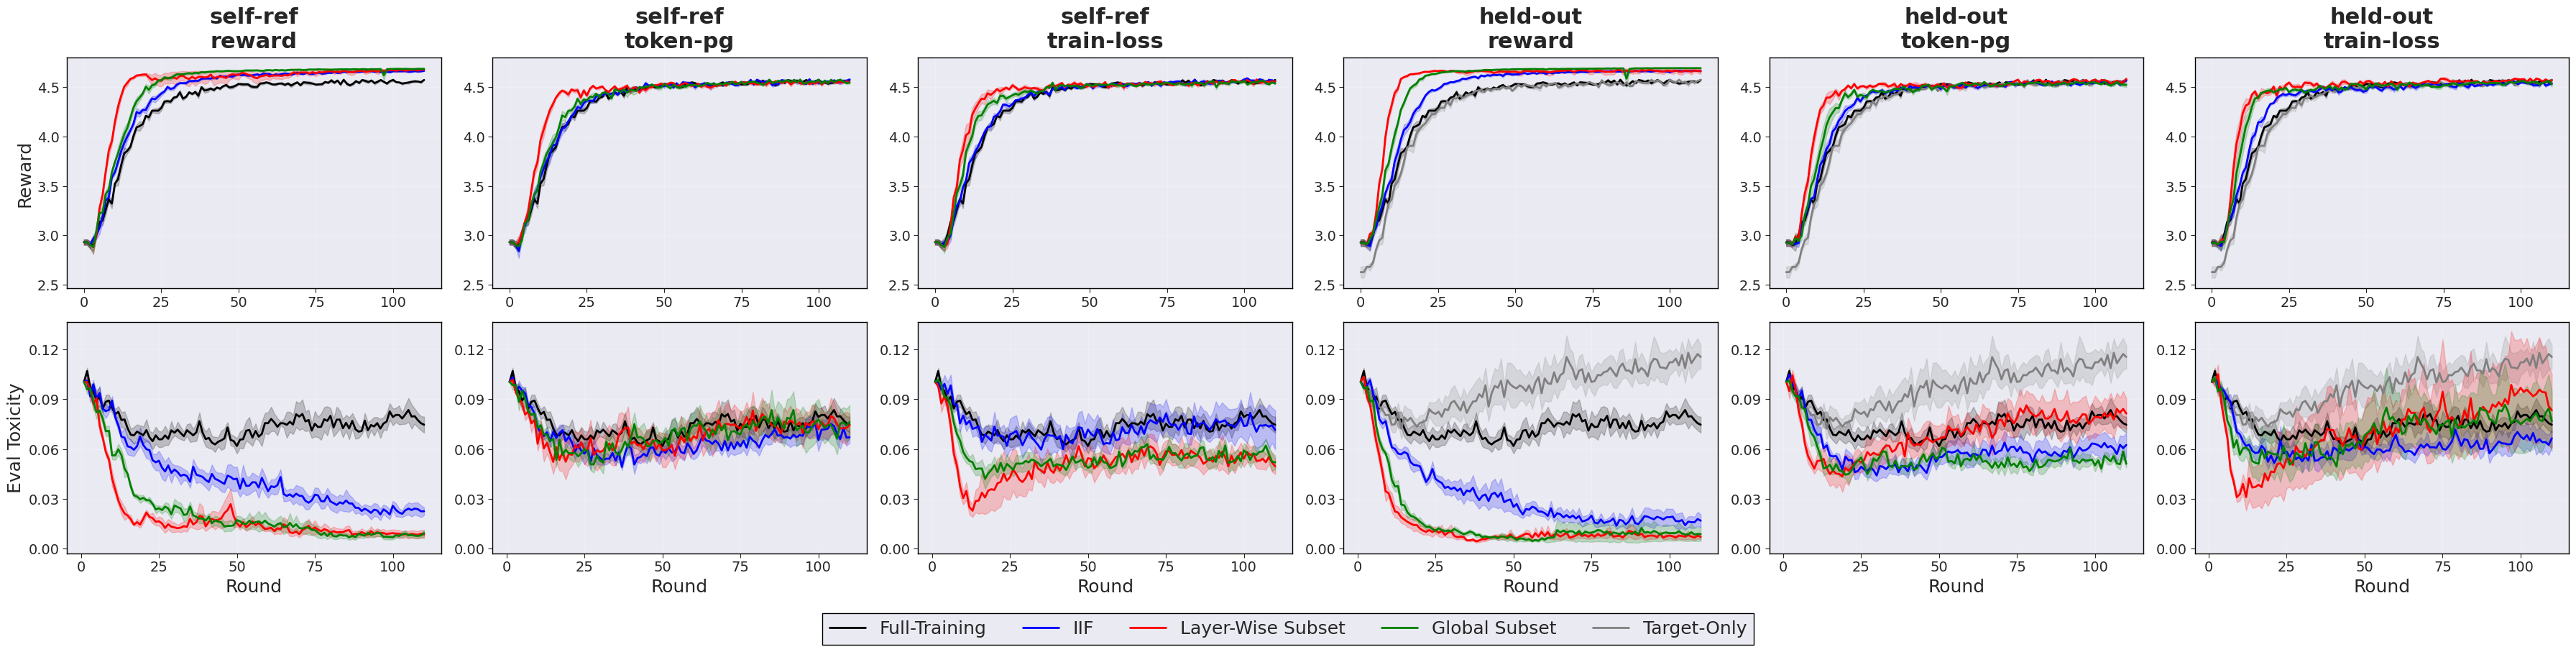


  self-ref / reward
Method               Seeds   Reward                 Batch Tox              Eval Tox              
-----------------------------------------------------------------------------------------------
FullTraining-LoRA    5       4.5739 +/- 0.0057      0.0687 +/- 0.0071      0.0746 +/- 0.0048     
IIF-LoRA             5       4.6659 +/- 0.0015      0.0176 +/- 0.0018      0.0226 +/- 0.0024     
LayerWiseSubset-LoRA 5       4.6776 +/- 0.0115      0.0086 +/- 0.0024      0.0086 +/- 0.0023     
GlobalSubset-LoRA    5       4.6869 +/- 0.0052      0.0104 +/- 0.0021      0.0094 +/- 0.0021     

  self-ref / token-pg
Method               Seeds   Reward                 Batch Tox              Eval Tox              
-----------------------------------------------------------------------------------------------
FullTraining-LoRA    5       4.5739 +/- 0.0057      0.0687 +/- 0.0071      0.0746 +/- 0.0048     
IIF-LoRA             5       4.5790 +/- 0.0026      0.0503 +/- 0.0056      0.0

In [5]:
# ============================================
# All-scenarios comparison grid (2 rows x N cols)
# ============================================
max_step = None  # exploratory grid: all rounds (the paper variants are set in PAPER_VARIANTS above)
scenario_names = list(SCENARIOS.keys())
n_scenarios = len(scenario_names)

fig, axes = plt.subplots(2, n_scenarios, figsize=(6 * n_scenarios, 4.5 * 2), squeeze=False)
fig.patch.set_facecolor('white')

for col, sname in enumerate(scenario_names):
    sdata = all_data.get(sname, {})
    for method_name in ALL_METHODS:
        if method_name not in sdata:
            continue
        data = sdata[method_name]
        color = METHOD_COLORS.get(method_name)
        display = LEGEND_NAMES.get(method_name, method_name)

        x, mean, std = data['steps'], data['reward_mean_mean'], data['reward_mean_std']
        if max_step is not None:
            mask = x <= max_step
            x, mean, std = x[mask], mean[mask], std[mask]
        axes[0, col].plot(x, mean, linewidth=2, color=color, label=display)
        if data['n_seeds'] > 1:
            axes[0, col].fill_between(x, mean - std, mean + std, color=color, alpha=0.2)

        ex, emean, estd = data['eval_toxicity_steps'], data['eval_toxicity_mean'], data['eval_toxicity_std']
        if len(ex) > 0:
            if max_step is not None:
                emask = ex <= max_step
                ex, emean, estd = ex[emask], emean[emask], estd[emask]
            axes[1, col].plot(ex, emean, linewidth=2, color=color, label=display)
            if data['n_seeds'] > 1:
                axes[1, col].fill_between(ex, emean - estd, emean + estd, color=color, alpha=0.2)

    # Formatting
    if col == 0:
        axes[0, col].set_ylabel('Reward', fontsize=18)
        axes[1, col].set_ylabel('Eval Toxicity', fontsize=18)
    axes[0, col].set_title(sname.replace(' / ', '\n'), fontsize=22, fontweight='bold', pad=10)
    axes[1, col].set_xlabel('Round', fontsize=18)
    for row_idx in range(2):
        ax = axes[row_idx, col]
        ax.grid(True, alpha=0.3, linewidth=0.5)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.0)
            spine.set_color('black')
        ax.tick_params(axis='both', which='major', labelsize=14, direction='out', length=4)
        ax.xaxis.set_major_locator(plt.MaxNLocator(5))
        ax.yaxis.set_major_locator(plt.MaxNLocator(5))
    axes[1, col].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.2f}'))

# Enforce shared axis limits per row (same metric across scenarios)
for row_idx in range(2):
    row_axes = [axes[row_idx, col] for col in range(n_scenarios)]
    all_xlims = [ax.get_xlim() for ax in row_axes]
    all_ylims = [ax.get_ylim() for ax in row_axes]
    shared_xlim = (min(l[0] for l in all_xlims), max(l[1] for l in all_xlims))
    shared_ylim = (min(l[0] for l in all_ylims), max(l[1] for l in all_ylims))
    for ax in row_axes:
        ax.set_xlim(shared_xlim)
        ax.set_ylim(shared_ylim)

# Shared legend at bottom (deduplicated)
handles, labels = [], []
for ax_row in axes:
    for ax in ax_row:
        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)
seen = {}
unique_handles, unique_labels = [], []
for h, l in zip(handles, labels):
    if l not in seen:
        seen[l] = True
        unique_handles.append(h)
        unique_labels.append(l)

fig.legend(unique_handles, unique_labels, loc='lower center', ncol=len(unique_labels),
           fontsize=18, frameon=True, edgecolor='black', fancybox=False, framealpha=1.0,
           bbox_to_anchor=(0.5, -0.02))

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


# ============================================
# Summary tables: per scenario + cross-scenario
# ============================================
for sname in scenario_names:
    sdata = all_data.get(sname, {})
    if not sdata:
        continue
    print(f"\n{'='*95}")
    print(f"  {sname}")
    print(f"{'='*95}")
    print(f"{'Method':<20} {'Seeds':<7} {'Reward':<22} {'Batch Tox':<22} {'Eval Tox':<22}")
    print("-" * 95)
    for name in ALL_METHODS:
        if name not in sdata:
            continue
        d = sdata[name]
        n = d['n_seeds']
        r = d['reward_mean_mean']
        rs = d['reward_mean_std']
        bt = d['batch_toxicity_mean']
        bts = d['batch_toxicity_std']
        et = d['eval_toxicity_mean']
        ets = d['eval_toxicity_std']
        r_str = f"{r[-1]:.4f} +/- {rs[-1]:.4f}" if n > 1 else f"{r[-1]:.4f}"
        bt_str = f"{bt[-1]:.4f} +/- {bts[-1]:.4f}" if n > 1 and len(bt) > 0 else f"{bt[-1]:.4f}" if len(bt) > 0 else "N/A"
        et_str = f"{et[-1]:.4f} +/- {ets[-1]:.4f}" if n > 1 and len(et) > 0 else f"{et[-1]:.4f}" if len(et) > 0 else "N/A"
        print(f"{name:<20} {n:<7} {r_str:<22} {bt_str:<22} {et_str:<22}")
    print("=" * 95)

# Cross-scenario comparison
print(f"\n{'='*130}")
print(f"Cross-Scenario: Final Reward / Eval Toxicity")
print(f"{'='*130}")
print(f"{'Method':<20}", end="")
for sname in scenario_names:
    short = sname.split(' / ')[1] if ' / ' in sname else sname
    print(f" {short:>12} / {'tox':>6} |", end="")
print()
print("-" * 130)
for method_name in ALL_METHODS:
    display = LEGEND_NAMES.get(method_name, method_name)
    print(f"{display:<20}", end="")
    for sname in scenario_names:
        sdata = all_data.get(sname, {})
        if method_name in sdata:
            d = sdata[method_name]
            r = d['reward_mean_mean'][-1] if len(d['reward_mean_mean']) > 0 else float('nan')
            t = d['eval_toxicity_mean'][-1] if len(d['eval_toxicity_mean']) > 0 else float('nan')
            print(f" {r:12.4f} / {t:6.4f} |", end="")
        else:
            print(f" {'N/A':>12} / {'N/A':>6} |", end="")
    print()
print("=" * 130)

## Judge Robustness: Final-Checkpoint Toxicity under Four Classifiers

Re-scores the final checkpoints (`RLHF/eval/rescore_final.py`) on the same 500 evaluation prompts with the paper judge (DaNLP), the reward model (LFTW), and two English classifiers (s-nlp, toxic-bert). Produces `judges_<scenario>.pdf` + `judges_legend.pdf` for both scoring backends, with a log y-axis shared across scenarios and backends: exact straight into `Paper/ICLR/Figures/RLHF/` (appendix `fig:RLHF-judges`), compressed into `figures/compressed_judges_*.pdf` (companion of `adxtab:rlhf-scoring-backend`, not in the paper).


Base model: DaNLP=0.0782  LFTW=0.0982  s-nlp=0.2060  toxic-bert=0.1920
  + [exact] self-ref / reward      Full-Training      5 seeds  DaNLP=0.0698  LFTW=0.0020  s-nlp=0.0086  toxic-bert=0.0085


  + [exact] self-ref / reward      IIF                5 seeds  DaNLP=0.0193  LFTW=0.0006  s-nlp=0.0001  toxic-bert=0.0008


  + [exact] self-ref / reward      Layer-Wise Subset  5 seeds  DaNLP=0.0100  LFTW=0.0002  s-nlp=0.0000  toxic-bert=0.0008
  + [exact] self-ref / reward      Global Subset      5 seeds  DaNLP=0.0074  LFTW=0.0001  s-nlp=0.0000  toxic-bert=0.0007


  + [exact] self-ref / train-loss  Full-Training      5 seeds  DaNLP=0.0698  LFTW=0.0020  s-nlp=0.0086  toxic-bert=0.0085


  + [exact] self-ref / train-loss  IIF                5 seeds  DaNLP=0.0682  LFTW=0.0036  s-nlp=0.0059  toxic-bert=0.0067
  + [exact] self-ref / train-loss  Layer-Wise Subset  5 seeds  DaNLP=0.0520  LFTW=0.0010  s-nlp=0.0041  toxic-bert=0.0050


...

  + [cmp] held-out / reward      Layer-Wise Subset  5 seeds  DaNLP=0.0056  LFTW=0.0005  s-nlp=0.0001  toxic-bert=0.0009
  + [cmp] held-out / reward      Global Subset      5 seeds  DaNLP=0.0155  LFTW=0.0001  s-nlp=0.0000  toxic-bert=0.0006


  + [cmp] held-out / train-loss  Full-Training      5 seeds  DaNLP=0.0698  LFTW=0.0020  s-nlp=0.0086  toxic-bert=0.0085


  + [cmp] held-out / train-loss  IIF                5 seeds  DaNLP=0.0540  LFTW=0.0011  s-nlp=0.0085  toxic-bert=0.0063
  + [cmp] held-out / train-loss  Layer-Wise Subset  5 seeds  DaNLP=0.0889  LFTW=0.0022  s-nlp=0.0076  toxic-bert=0.0067


  + [cmp] held-out / train-loss  Global Subset      5 seeds  DaNLP=0.0713  LFTW=0.0024  s-nlp=0.0064  toxic-bert=0.0058
    [exact] [self-ref / reward] Full-Training: DaNLP=0.0698  LFTW=0.0020  s-nlp=0.0086  toxic-bert=0.0085
    [exact] [self-ref / reward] IIF: DaNLP=0.0193  LFTW=0.0006  s-nlp=0.0001  toxic-bert=0.0008
    [exact] [self-ref / reward] Layer-Wise Subset: DaNLP=0.0100  LFTW=0.0002  s-nlp=0.0000  toxic-bert=0.0008
    [exact] [self-ref / reward] Global Subset: DaNLP=0.0074  LFTW=0.0001  s-nlp=0.0000  toxic-bert=0.0007


    -> Saved: ./figures/paper_exact/judges_self-ref_reward.pdf


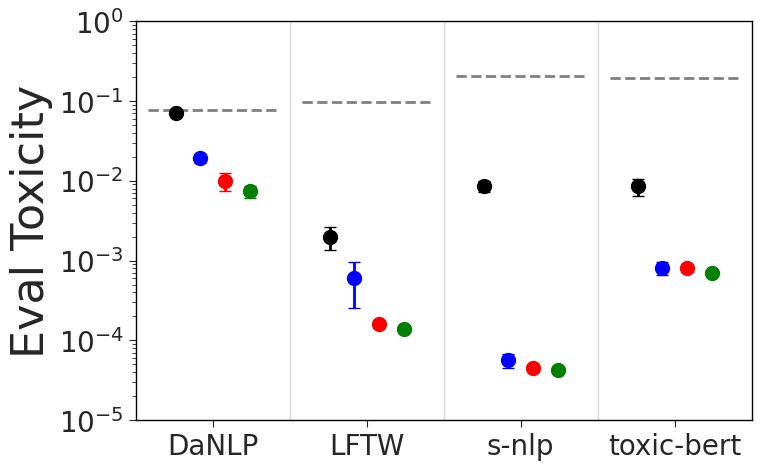

    [exact] [self-ref / train-loss] Full-Training: DaNLP=0.0698  LFTW=0.0020  s-nlp=0.0086  toxic-bert=0.0085
    [exact] [self-ref / train-loss] IIF: DaNLP=0.0682  LFTW=0.0036  s-nlp=0.0059  toxic-bert=0.0067
    [exact] [self-ref / train-loss] Layer-Wise Subset: DaNLP=0.0520  LFTW=0.0010  s-nlp=0.0041  toxic-bert=0.0050
    [exact] [self-ref / train-loss] Global Subset: DaNLP=0.0528  LFTW=0.0015  s-nlp=0.0040  toxic-bert=0.0034


    -> Saved: ./figures/paper_exact/judges_self-ref_train-loss.pdf


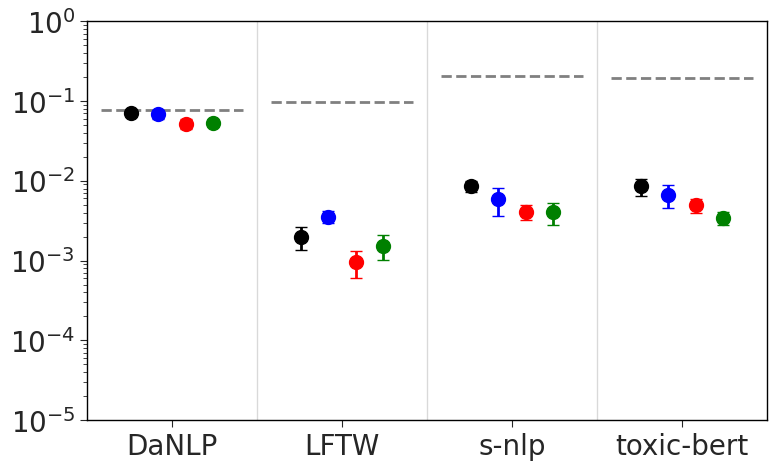

    [exact] [held-out / reward] Full-Training: DaNLP=0.0698  LFTW=0.0020  s-nlp=0.0086  toxic-bert=0.0085
    [exact] [held-out / reward] IIF: DaNLP=0.0171  LFTW=0.0001  s-nlp=0.0000  toxic-bert=0.0006
    [exact] [held-out / reward] Layer-Wise Subset: DaNLP=0.0068  LFTW=0.0002  s-nlp=0.0000  toxic-bert=0.0010
    [exact] [held-out / reward] Global Subset: DaNLP=0.0084  LFTW=0.0001  s-nlp=0.0000  toxic-bert=0.0006


    -> Saved: ./figures/paper_exact/judges_held-out_reward.pdf


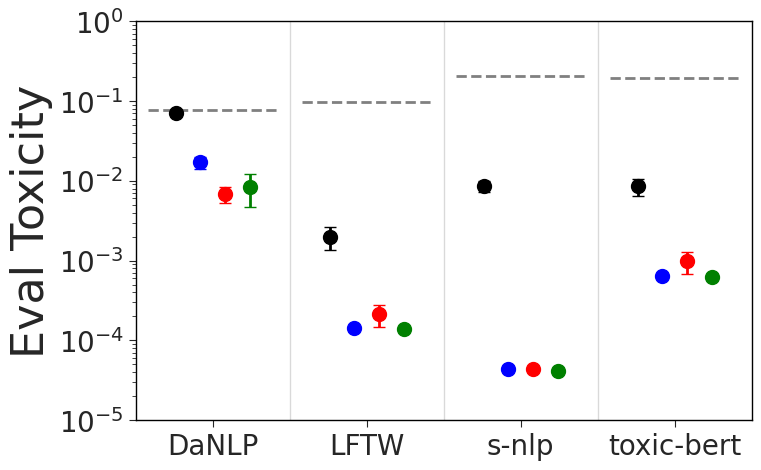

    [exact] [held-out / train-loss] Full-Training: DaNLP=0.0698  LFTW=0.0020  s-nlp=0.0086  toxic-bert=0.0085
    [exact] [held-out / train-loss] IIF: DaNLP=0.0623  LFTW=0.0021  s-nlp=0.0089  toxic-bert=0.0064
    [exact] [held-out / train-loss] Layer-Wise Subset: DaNLP=0.0901  LFTW=0.0016  s-nlp=0.0038  toxic-bert=0.0047
    [exact] [held-out / train-loss] Global Subset: DaNLP=0.0799  LFTW=0.0006  s-nlp=0.0092  toxic-bert=0.0064


    -> Saved: ./figures/paper_exact/judges_held-out_train-loss.pdf


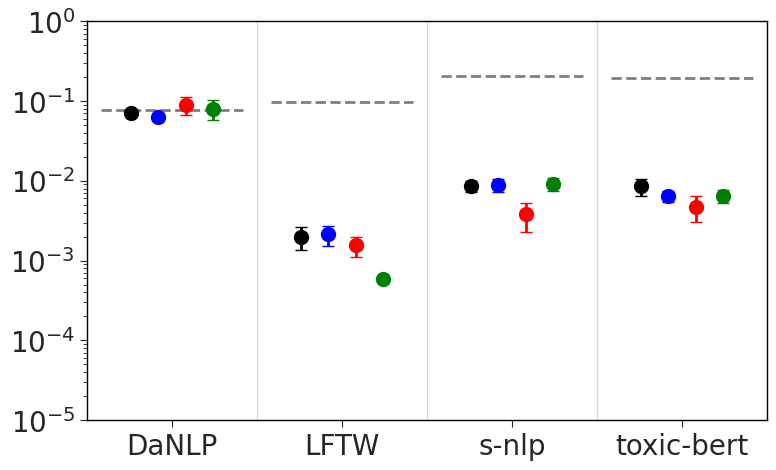

    [cmp] [self-ref / reward] Full-Training: DaNLP=0.0698  LFTW=0.0020  s-nlp=0.0086  toxic-bert=0.0085
    [cmp] [self-ref / reward] IIF: DaNLP=0.0277  LFTW=0.0002  s-nlp=0.0001  toxic-bert=0.0007
    [cmp] [self-ref / reward] Layer-Wise Subset: DaNLP=0.0072  LFTW=0.0001  s-nlp=0.0000  toxic-bert=0.0006
    [cmp] [self-ref / reward] Global Subset: DaNLP=0.0122  LFTW=0.0001  s-nlp=0.0000  toxic-bert=0.0006


    -> Saved: ./figures/paper_cmp/judges_self-ref_reward.pdf


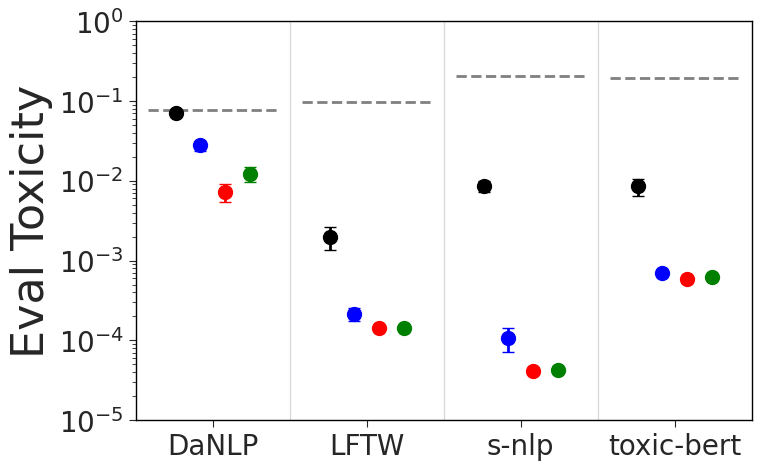

    [cmp] [self-ref / train-loss] Full-Training: DaNLP=0.0698  LFTW=0.0020  s-nlp=0.0086  toxic-bert=0.0085
    [cmp] [self-ref / train-loss] IIF: DaNLP=0.0598  LFTW=0.0012  s-nlp=0.0045  toxic-bert=0.0044
    [cmp] [self-ref / train-loss] Layer-Wise Subset: DaNLP=0.0738  LFTW=0.0015  s-nlp=0.0050  toxic-bert=0.0065
    [cmp] [self-ref / train-loss] Global Subset: DaNLP=0.0620  LFTW=0.0021  s-nlp=0.0105  toxic-bert=0.0068


    -> Saved: ./figures/paper_cmp/judges_self-ref_train-loss.pdf


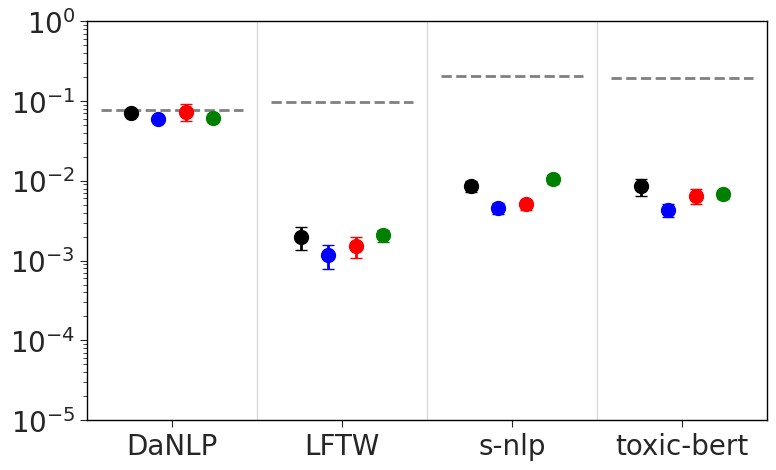

    [cmp] [held-out / reward] Full-Training: DaNLP=0.0698  LFTW=0.0020  s-nlp=0.0086  toxic-bert=0.0085
    [cmp] [held-out / reward] IIF: DaNLP=0.0180  LFTW=0.0001  s-nlp=0.0001  toxic-bert=0.0006
    [cmp] [held-out / reward] Layer-Wise Subset: DaNLP=0.0056  LFTW=0.0005  s-nlp=0.0001  toxic-bert=0.0009
    [cmp] [held-out / reward] Global Subset: DaNLP=0.0155  LFTW=0.0001  s-nlp=0.0000  toxic-bert=0.0006


    -> Saved: ./figures/paper_cmp/judges_held-out_reward.pdf


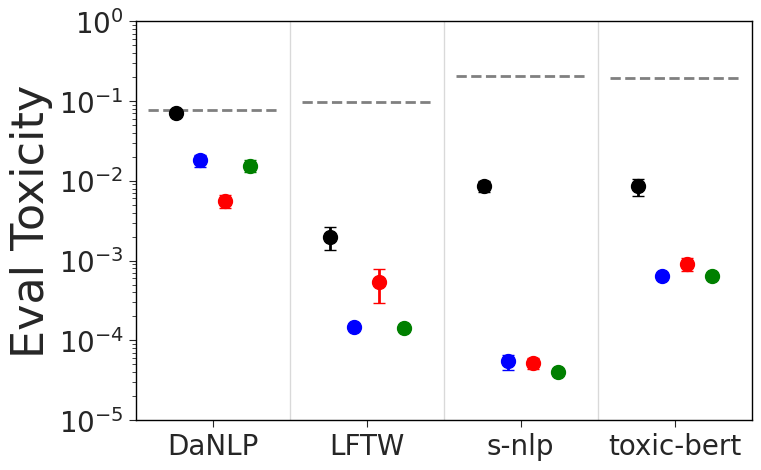

    [cmp] [held-out / train-loss] Full-Training: DaNLP=0.0698  LFTW=0.0020  s-nlp=0.0086  toxic-bert=0.0085
    [cmp] [held-out / train-loss] IIF: DaNLP=0.0540  LFTW=0.0011  s-nlp=0.0085  toxic-bert=0.0063
    [cmp] [held-out / train-loss] Layer-Wise Subset: DaNLP=0.0889  LFTW=0.0022  s-nlp=0.0076  toxic-bert=0.0067
    [cmp] [held-out / train-loss] Global Subset: DaNLP=0.0713  LFTW=0.0024  s-nlp=0.0064  toxic-bert=0.0058


    -> Saved: ./figures/paper_cmp/judges_held-out_train-loss.pdf


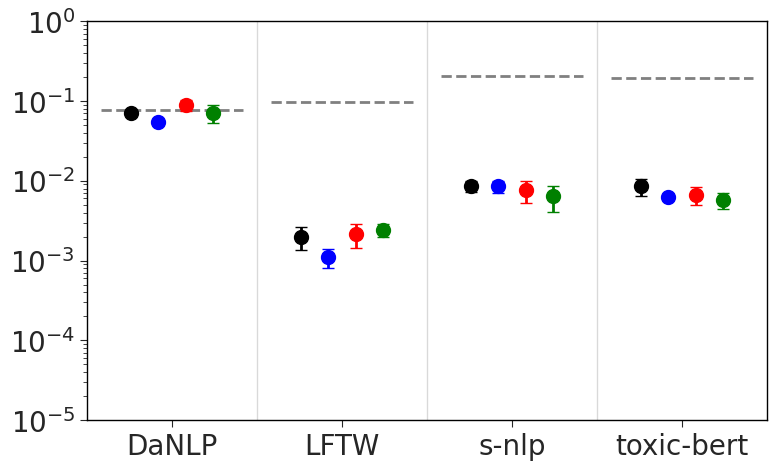

Saved legend: ./figures/paper_exact/judges_legend.pdf


Saved legend: ./figures/paper_cmp/judges_legend.pdf


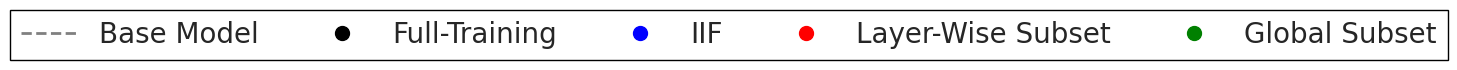

In [6]:
# ============================================
# Judge robustness: final-checkpoint toxicity under four classifiers, per scoring backend
# Inputs: RLHF/eval/rescore_final.py -> <run>/rescore_final.json and {out_dir}/rescore_BASE.json
# (same 500 evaluation prompts and decoding as the in-training evaluator; mean toxicity prob).
# Outputs: judges_<scenario>.pdf + judges_legend.pdf (paper style, same margins as the training-curve figures);
#          exact -> Paper/ICLR/Figures/RLHF (fig:RLHF-judges), compressed -> figures/compressed_judges_* (not in the paper)
# ============================================
from matplotlib.ticker import LogLocator, NullFormatter

JUDGES = ['danlp', 'lftw', 'snlp', 'detoxify']
JUDGE_LABELS = {'danlp': 'DaNLP', 'lftw': 'LFTW', 'snlp': 's-nlp', 'detoxify': 'toxic-bert'}
JUDGE_SCENARIOS = PAPER_SCENARIOS
JUDGE_METHODS = PAPER_METHODS   # same order/colors as legend.pdf
BASE_COLOR, BASE_LABEL = 'gray', 'Base Model'
# Same layout constants as the training-curve figures (self-contained in case that cell has not run)
LEFTMOST_SCENARIOS = {'self-ref / reward', 'held-out / reward'}   # leftmost in each row -> y-axis label
LEFTMOST_LEFT, OTHER_LEFT, SHARED_RIGHT, SHARED_TOP = 0.20, 0.12, 0.97, 0.98

def _load_rescore(path):
    with open(path) as f:
        d = json.load(f)
    return {j: d['judges'][j]['mean_toxicity_prob'] for j in JUDGES}

base_scores = _load_rescore(f"{out_dir}/rescore_BASE.json")
print("Base model: " + "  ".join(f"{JUDGE_LABELS[j]}={base_scores[j]:.4f}" for j in JUDGES))

# judge_data[scoring][scenario][method] = {'mean': {judge: m}, 'se': {judge: se}, 'n_seeds': n}
judge_data = {}
for scoring in SCORING_SUFFIX:
    judge_data[scoring] = {}
    for sname in JUDGE_SCENARIOS:
        scfg = SCENARIOS[sname]
        judge_data[scoring][sname] = {}
        for method_name in JUDGE_METHODS:
            per_seed = []
            for seed in _discover_seeds(method_name, scfg, scoring):
                p = f"{out_dir}/{_dir_name(method_name, seed, scfg, scoring)}/rescore_final.json"
                if os.path.exists(p):
                    per_seed.append(_load_rescore(p))
            if not per_seed:
                print(f"  - [{scoring}] {sname} / {method_name}: no rescore_final.json")
                continue
            arr = {j: np.array([s[j] for s in per_seed]) for j in JUDGES}
            judge_data[scoring][sname][method_name] = {
                'mean': {j: arr[j].mean() for j in JUDGES},
                'se': {j: arr[j].std() / np.sqrt(len(arr[j])) for j in JUDGES},   # same SE convention as load_method
                'n_seeds': len(per_seed),
            }
            print(f"  + [{scoring}] {sname:22s} {LEGEND_NAMES[method_name]:18s} {len(per_seed)} seeds  "
                  + "  ".join(f"{JUDGE_LABELS[j]}={arr[j].mean():.4f}" for j in JUDGES))

# Shared log y-range across scenarios AND backends (identical axes when placed side by side)
vals = [base_scores[j] for j in JUDGES]
for scoring in judge_data:
    for sname in JUDGE_SCENARIOS:
        for md in judge_data[scoring][sname].values():
            for j in JUDGES:
                vals += [max(md['mean'][j] - md['se'][j], 1e-6), md['mean'][j] + md['se'][j]]
y_min = 10 ** np.floor(np.log10(min(vals)))
y_max = 10 ** np.ceil(np.log10(max(vals)))

n_groups = len(JUDGES)
x_centers = np.arange(n_groups)
dodge = 0.8 / (len(JUDGE_METHODS) + 1)
JUDGE_BOTTOM = 0.14   # room for the judge names (no x-label)

def judge_fig_path(scoring, name):
    """exact -> paper (fig:RLHF-judges); compressed -> aux_dir (companion of the scoring-backend table, not in the paper)."""
    return paper_fig_path(scoring, name) if scoring == 'exact' else os.path.join(aux_dir, PAPER_FIG_PREFIX[scoring] + name)

for scoring in SCORING_SUFFIX:
    for sname in JUDGE_SCENARIOS:
        sname_safe = sname.replace(' / ', '_').replace(' ', '_')
        fig, ax = plt.subplots(figsize=(8, 4.75))
        fig.patch.set_facecolor('white')
        ax.set_facecolor('white')

        # Untuned base model: dashed reference per judge
        for gi, j in enumerate(JUDGES):
            ax.hlines(base_scores[j], gi - 0.42, gi + 0.42, color=BASE_COLOR, linestyle='--', linewidth=2)

        for si, method_name in enumerate(JUDGE_METHODS):
            md = judge_data[scoring][sname].get(method_name)
            if md is None:
                continue
            offs = (si - (len(JUDGE_METHODS) - 1) / 2) * dodge
            means = np.array([md['mean'][j] for j in JUDGES])
            ses = np.array([md['se'][j] for j in JUDGES])
            lower = np.minimum(ses, means - y_min * 1.05)   # keep the lower error bar inside the log axis
            ax.errorbar(x_centers + offs, means, yerr=[lower, ses], fmt='o', color=METHOD_COLORS[method_name],
                        markersize=10, capsize=4, linewidth=2, elinewidth=2)
            print(f"    [{scoring}] [{sname}] {LEGEND_NAMES[method_name]}: "
                  + "  ".join(f"{JUDGE_LABELS[j]}={m:.4f}" for j, m in zip(JUDGES, means)))

        # Light separators between judge groups (no grid)
        for gi in range(1, n_groups):
            ax.axvline(gi - 0.5, color='black', alpha=0.15, linewidth=1)

        ax.set_yscale('log')
        ax.set_ylim(y_min, y_max)
        ax.yaxis.set_major_locator(LogLocator(base=10, numticks=8))
        ax.yaxis.set_minor_formatter(NullFormatter())
        ax.set_xlim(-0.5, n_groups - 0.5)
        ax.set_xticks(x_centers)
        ax.set_xticklabels([JUDGE_LABELS[j] for j in JUDGES])
        if sname in LEFTMOST_SCENARIOS:
            ax.set_ylabel('Eval Toxicity', fontsize=32)

        ax.grid(False)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.0)
            spine.set_color('black')
        ax.tick_params(axis='both', which='major', labelsize=20, direction='out', length=5)
        ax.tick_params(axis='y', which='minor', direction='out', length=3)

        left = LEFTMOST_LEFT if sname in LEFTMOST_SCENARIOS else OTHER_LEFT
        fig.subplots_adjust(left=left, right=SHARED_RIGHT, top=SHARED_TOP, bottom=JUDGE_BOTTOM)
        filepath = judge_fig_path(scoring, f"judges_{sname_safe}.pdf")
        fig.savefig(filepath, format='pdf', facecolor='white')
        print(f"    -> Saved: {filepath}")
        plt.show()

# Standalone legend (base reference + methods), same style as legend.pdf; exact -> paper, compressed -> aux_dir
handles = [plt.Line2D([0], [0], color=BASE_COLOR, linestyle='--', linewidth=2)]
labels = [BASE_LABEL]
for m in JUDGE_METHODS:
    handles.append(plt.Line2D([0], [0], color=METHOD_COLORS[m], marker='o', markersize=10, linestyle='none'))
    labels.append(LEGEND_NAMES[m])
fig_leg, ax_leg = plt.subplots(figsize=(8, 0.5))
ax_leg.set_axis_off()
legend = fig_leg.legend(handles, labels, loc='center', ncol=len(labels), fontsize=20,
                        frameon=True, edgecolor='black', fancybox=False, framealpha=1.0)
legend.get_frame().set_facecolor('white')
fig_leg.patch.set_facecolor('white')
for scoring in SCORING_SUFFIX:
    filepath = judge_fig_path(scoring, 'judges_legend.pdf')
    fig_leg.savefig(filepath, format='pdf', bbox_inches='tight', facecolor='white')
    print(f"Saved legend: {filepath}")
plt.show()
